# Predicting Wine Price from Expanded Text with Partially Frozen ModernBERT

`description` に `points`、産地、品種、ワイナリーなどの構造化変数をラベル付きテキストとして連結し、$\log(\mathrm{price})$ を予測する回帰モデルです。[`answerdotai/ModernBERT-base`](https://huggingface.co/answerdotai/ModernBERT-base) の全層は更新せず、encoderの最後の4層と回帰headだけをfine-tuningします。

## 基本情報

- 主題: 拡張テキストを入力したModernBERTの部分的fine-tuning
- 作成者: 荒田禎之
- 使用データ: Wine Review
- 入力: レビュー本文と構造化変数を連結したテキスト
- 目的変数: ワイン価格の自然対数
- 学習対象: encoderの最後の4層、最終LayerNorm、prediction head、回帰層

層の凍結は、Hugging Face公式ガイドの [`model.base_model.parameters()` に対して `requires_grad=False` を設定する方法](https://huggingface.co/transformers/v4.2.2/training.html#freezing-the-encoder) に沿います。参照ページはModernBERT登場前のlegacy documentationですが、PyTorchの `requires_grad` を使う原則をModernBERTの層構造へ適用しています。

This notebook includes code and explanations generated with OpenAI Codex.


In [26]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U "transformers>=4.48.0" datasets accelerate scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
SEED = 42

## 1. データの読み込み、重複除外、入力テキスト作成

同じレビュー本文が訓練データと評価データに分かれないよう、`description` が重複する行を除外します。構造化変数の欠損は `Unknown` として入力テキストへ明示します。

### 構造化変数のテキスト化

各変数の意味を説明する長い自然文は全サンプルで同じ内容を繰り返し、レビュー本文に使えるトークン数を減らします。そのため、変数を識別するために必要な短いフィールド名だけを残し、次の形式へ変換します。

```text
Points: 94 | Country: US | Designation: Reserve |
Province: California | Region 1: Napa Valley |
Region 2: Unknown | Variety: Cabernet Sauvignon |
Winery: Example Winery | Review: A rich and structured red wine...
```

フィールド名を完全に削除すると、例えば `France` が国、州、地域のどれを表すか区別しにくくなります。短いラベルによって変数の役割を維持しながら、長い説明文によるトークン消費を避けます。

`Unknown` はトークンを消費しますが、値が欠損している事実をモデルへ伝えられるため残します。推論時にも学習時と同じフィールド名、順序、欠損値表現を使う必要があります。

レビュー本文、価格、評価点、国、銘柄名、産地、品種、ワイナリーをCSVから読み込む。本文と正の価格がある行を残し、同じ本文を持つ重複レビューを除外する。欠損や空文字を `Unknown` に統一し、構造化変数を短いフィールド名付きテキストへ変換してレビュー本文の前に連結する。最後に価格の自然対数を回帰ラベルとして作成する。


In [ ]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

metadata_columns = [
    "points",
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
read_columns = ["description", "price"] + metadata_columns

df = pd.read_csv(csv_path, usecols=read_columns)
rows_before = len(df)
model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        read_columns,
    ]
    .drop_duplicates(subset=["description"])
    .reset_index(drop=True)
)


def format_metadata_value(value):
    if pd.isna(value) or str(value).strip() == "":
        return "Unknown"
    if isinstance(value, (float, np.floating)) and value.is_integer():
        return str(int(value))
    return str(value).strip()


def build_model_text(
    description,
    points=None,
    country=None,
    designation=None,
    province=None,
    region_1=None,
    region_2=None,
    variety=None,
    winery=None,
):
    fields = [
        f"Points: {format_metadata_value(points)}",
        f"Country: {format_metadata_value(country)}",
        f"Designation: {format_metadata_value(designation)}",
        f"Province: {format_metadata_value(province)}",
        f"Region 1: {format_metadata_value(region_1)}",
        f"Region 2: {format_metadata_value(region_2)}",
        f"Variety: {format_metadata_value(variety)}",
        f"Winery: {format_metadata_value(winery)}",
        f"Review: {format_metadata_value(description)}",
    ]
    return " | ".join(fields)


model_data["text"] = model_data.apply(
    lambda row: build_model_text(
        description=row["description"],
        points=row["points"],
        country=row["country"],
        designation=row["designation"],
        province=row["province"],
        region_1=row["region_1"],
        region_2=row["region_2"],
        variety=row["variety"],
        winery=row["winery"],
    ),
    axis=1,
)
model_data["label"] = np.log(model_data["price"]).astype("float32")

print(f"Loaded: {csv_path.resolve()}")
print(f"Original rows: {rows_before:,}")
print(f"Rows used after filtering and deduplication: {len(model_data):,}")
display(model_data[["description", "text", "price", "label"]].head())
display(model_data["label"].describe().rename("log_price").to_frame())

### 元のレビュー本文とコンパクトな拡張テキストの文字数

短いフィールド名で構造化変数を追加した結果、入力長がレビュー本文のみの場合からどの程度増えるか確認します。

元の `description` と、構造化変数をコンパクトな形式で追加した `text` の文字数をそれぞれ計算する。平均、四分位点、90・95・99パーセンタイル、最大値を比較し、両方の分布を同じ密度グラフに重ねる。入力長の増加を確認し、後続の最大トークン数で切り捨てが起きそうか判断する参考にする。

文字数はトークン数と一致しないため、厳密に `MAX_LENGTH` を検討する場合はtokenizerによるトークン数分布も確認する。


,count,mean,std,min,50%,75%,90%,95%,99%,max
description_length,111567.0,244.477328,67.187402,20.0,239.0,285.0,331.0,362.0,431.0,829.0
expanded_text_length,111567.0,427.605663,69.230580,206.0,422.0,469.0,517.0,549.0,618.0,1008.0


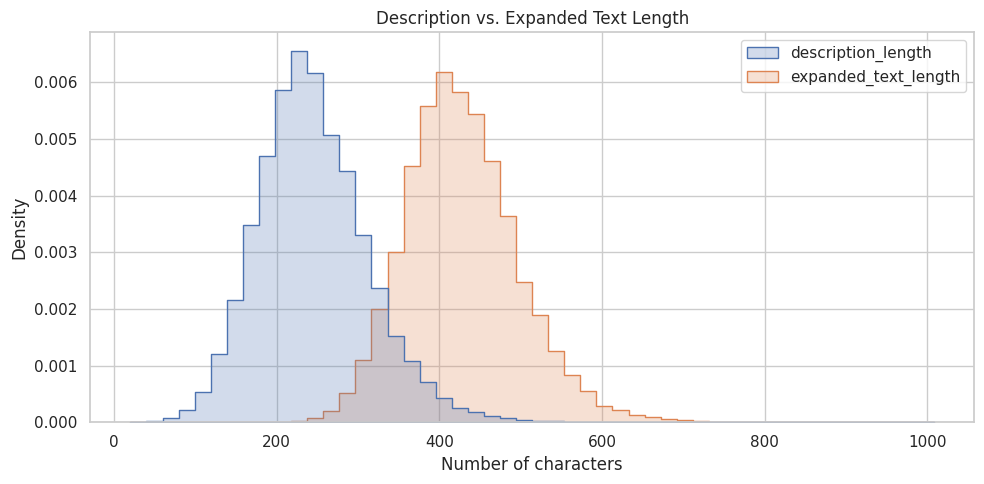

In [28]:
text_lengths = pd.DataFrame({
    "description_length": model_data["description"].str.len(),
    "expanded_text_length": model_data["text"].str.len(),
})
display(
    text_lengths.describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).T
)

plt.figure(figsize=(10, 5))
sns.histplot(
    text_lengths,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Description vs. Expanded Text Length")
plt.xlabel("Number of characters")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## 2. ModernBERTの準備、層の凍結、データ分割

80%を訓練、10%を検証、10%を最終テストに使います。`MAX_LENGTH` は文字数ではなくトークン数です。拡張テキストが切り詰められる場合は、GPUメモリを確認しながら増やしてください。

`answerdotai/ModernBERT-base` のtokenizerと、1つの連続値を出力する回帰モデルを読み込む。必要なら `MAX_ROWS` 件を固定乱数で抽出する。

Hugging Face公式ガイドと同様に、最初に `model.base_model.parameters()` の `requires_grad` をすべて `False` にして事前学習済みencoderを凍結する。その後、ModernBERTの22層から最後の `NUM_UNFROZEN_LAYERS` 層だけを学習可能に戻す。

最後のencoder層の出力に適用される `final_norm` と、タスク用に初期化された `head`、`classifier` も学習対象にする。学習可能パラメータ数と割合を表示し、想定どおりに凍結できたことを `assert` で検証してから、データを8:1:1に分割する。


In [29]:
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 176 # 160
MAX_ROWS = None  # 例: 10_000。全データを使う場合は None
NUM_UNFROZEN_LAYERS = 2  # encoderの最後から何層を学習するか

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

# 公式ガイドの方法に沿って、まず事前学習済みencoder全体を凍結する。
for parameter in model.base_model.parameters():
    parameter.requires_grad = False

encoder_layers = model.base_model.layers
num_encoder_layers = len(encoder_layers)
if not 1 <= NUM_UNFROZEN_LAYERS <= num_encoder_layers:
    raise ValueError(
        f"NUM_UNFROZEN_LAYERS must be between 1 and {num_encoder_layers}, "
        f"but got {NUM_UNFROZEN_LAYERS}."
    )

# encoderの最後の数層だけを学習可能に戻す。
for layer in encoder_layers[-NUM_UNFROZEN_LAYERS:]:
    for parameter in layer.parameters():
        parameter.requires_grad = True

# 最終encoder層の後に適用されるLayerNormを学習する。
for parameter in model.base_model.final_norm.parameters():
    parameter.requires_grad = True

# タスク固有のprediction headと回帰層は必ず学習する。
for module in (model.head, model.classifier):
    for parameter in module.parameters():
        parameter.requires_grad = True

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
first_unfrozen_layer = num_encoder_layers - NUM_UNFROZEN_LAYERS

print(f"Encoder layers: {num_encoder_layers}")
print(
    "Unfrozen encoder layers: "
    f"{list(range(first_unfrozen_layer, num_encoder_layers))}"
)
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable ratio: {trainable_parameters / total_parameters:.2%}")

# 設定どおりに凍結できていることを検証する。
assert not any(
    parameter.requires_grad for parameter in model.base_model.embeddings.parameters()
)
assert all(
    parameter.requires_grad
    for layer in encoder_layers[-NUM_UNFROZEN_LAYERS:]
    for parameter in layer.parameters()
)
assert all(parameter.requires_grad for parameter in model.head.parameters())
assert all(parameter.requires_grad for parameter in model.classifier.parameters())

dataset = Dataset.from_pandas(
    model_data[["text", "label"]], preserve_index=False
)
train_holdout = dataset.train_test_split(test_size=0.2, seed=SEED)
valid_test = train_holdout["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": train_holdout["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"],
})

print(dataset)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoder layers: 22
Unfrozen encoder layers: [20, 21]
Trainable parameters: 10,622,209
Total parameters: 149,605,633
Trainable ratio: 7.10%
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
})


### 拡張テキストのトークン数分布

文字数ではなく、ModernBERTのtokenizerが生成するトークン数を確認する。`add_special_tokens=True` とするため、特殊トークンを含む実際のモデル入力長に対応する。

`truncation=False` と `padding=False` により、この段階では切り捨てやpaddingを行わず、コンパクトなフィールドとレビュー本文を連結した拡張テキスト本来のトークン数を測る。全データを一度にメモリへ載せないよう、Hugging Face Datasetの `map()` を使って1,000件ずつ処理する。

要約統計とヒストグラムに加え、現在の `MAX_LENGTH` を超えて後続のtokenizationで切り捨て対象となるデータの件数と割合を表示する。これにより、構造化変数を追加した際の入力長と、`MAX_LENGTH` による情報損失を確認できる。


Counting tokens:   0%|          | 0/111567 [00:00<?, ? examples/s]

,token_length
count,111567.000000
mean,111.764312
std,17.143429
min,56.000000
50%,111.000000
75%,122.000000
90%,134.000000
95%,142.000000
99%,158.000000
max,248.000000


MAX_LENGTH: 176
切り捨て対象: 173件 (0.16%)


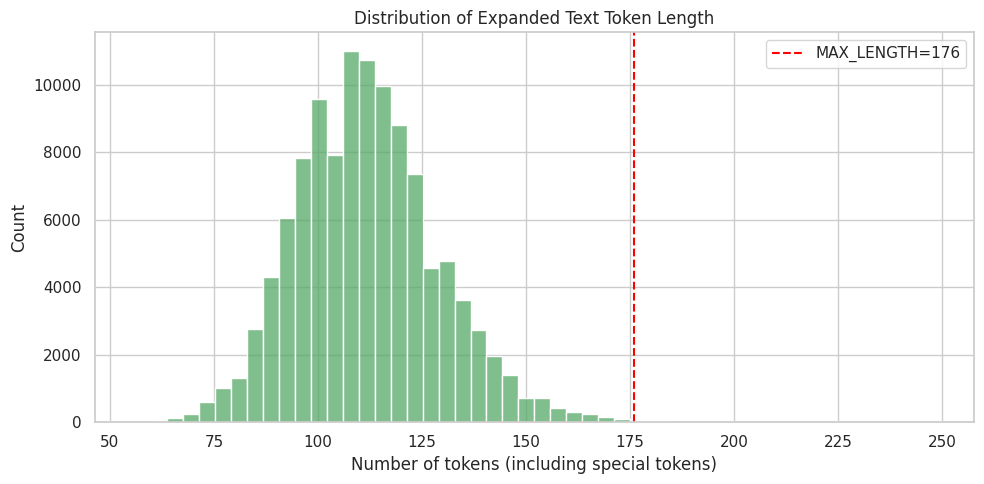

In [30]:
def count_tokens(batch):
    encoded = tokenizer(
        batch["text"],
        add_special_tokens=True,
        truncation=False,
        padding=False,
        return_length=True,
    )
    return {"token_length": encoded["length"]}


length_dataset = Dataset.from_pandas(
    model_data[["text"]],
    preserve_index=False,
).map(
    count_tokens,
    batched=True,
    batch_size=1_000,
    desc="Counting tokens",
)

model_data["token_length"] = np.asarray(
    length_dataset["token_length"],
    dtype=np.int32,
)

token_length_summary = model_data["token_length"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).rename("token_length")
display(token_length_summary.to_frame())

truncated_count = int((model_data["token_length"] > MAX_LENGTH).sum())
truncated_ratio = truncated_count / len(model_data)
print(f"MAX_LENGTH: {MAX_LENGTH}")
print(f"切り捨て対象: {truncated_count:,}件 ({truncated_ratio:.2%})")

plt.figure(figsize=(10, 5))
sns.histplot(model_data["token_length"], bins=50, color="#55A868")
plt.axvline(
    MAX_LENGTH,
    color="red",
    linestyle="--",
    label=f"MAX_LENGTH={MAX_LENGTH}",
)
plt.title("Distribution of Expanded Text Token Length")
plt.xlabel("Number of tokens (including special tokens)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Tokenization

拡張テキストをModernBERT用のtoken IDとattention maskへ変換する。`MAX_LENGTH=256` は文字数ではなく最大トークン数であり、長い入力の末尾は切り詰められる。メタデータをレビュー本文より先に配置しているため、切り詰め時にも構造化変数は残りやすい。

各データの切り詰め後のトークン数を `length` 列へ保存する。この列は、学習時に長さが近いデータを同じbatchへまとめ、動的paddingによる無駄な計算を減らすために使う。処理後は元の文字列列を削除する。


In [31]:
def tokenize(batch):
    encoded = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )
    encoded["length"] = [len(input_ids) for input_ids in encoded["input_ids"]]
    return encoded


tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset


Map:   0%|          | 0/89253 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask', 'length'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask', 'length'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask', 'length'],
        num_rows: 11157
    })
})

## 4. 評価指標

学習時の損失とRMSE・MAE・$R^2$ は log価格で計算します。参考として、ドル価格に戻したMAEも計算します。

`Trainer` が検証・評価時に使用する指標関数を定義する。モデル予測と正解ラベルを1次元へ整形し、log価格でRMSE、MAE、$R^2$ を計算する。さらに指数変換してドル価格へ戻したMAEも計算し、対数尺度と実価格尺度の両方で誤差を確認できるようにする。


In [32]:
def compute_metrics(eval_prediction):
    predictions = np.asarray(eval_prediction.predictions).reshape(-1)
    labels = np.asarray(eval_prediction.label_ids).reshape(-1)
    return {
        "rmse": mean_squared_error(labels, predictions) ** 0.5,
        "mae": mean_absolute_error(labels, predictions),
        "r2": r2_score(labels, predictions),
        "price_mae_usd": mean_absolute_error(
            np.exp(labels), np.exp(predictions)
        ),
    }

## 5. 最終層だけのfine-tuning

GPUが利用可能な場合はmixed precision（`fp16`）を有効にします。検証RMSEが改善しない状態が2回続いた場合は学習を停止します。

`Trainer` は `requires_grad=True` のパラメータについて勾配を計算し、optimizerで更新する。凍結したembeddingとencoder前半18層は更新せず、最後の4層、最終LayerNorm、prediction head、回帰層だけを学習する。

full fine-tuning版と比較しやすいよう、学習率、batch size、最大10 epoch、正則化、warmup、評価・保存頻度は元ノートブックの設定を維持する。勾配を2 step蓄積し、各epochの検証RMSEを監視する。2回連続で改善しなければearly stoppingし、終了時には最良checkpointを復元する。

`train_sampling_strategy="group_by_length"` により、トークン数が近いデータを同じbatchへまとめる。これにより、batch内の最長データへ揃える動的paddingの量を減らし、GPUの計算を効率化する。


In [33]:
training_args = TrainingArguments(
    output_dir="./wine-review-modernbert-expanded-freeze",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    train_sampling_strategy="group_by_length",
    length_column_name="length",
    num_train_epochs=7,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Usd
1,0.340127,0.174553,0.417795,0.315272,0.609851,12.967049
2,0.304101,0.178134,0.422059,0.312854,0.601848,12.721498
3,0.275931,0.166443,0.407974,0.319760,0.627978,13.288983
4,0.269958,0.142265,0.377180,0.287898,0.682019,12.168336
5,0.234707,0.135913,0.368664,0.280633,0.696217,11.739264
6,0.227514,0.130446,0.361174,0.271261,0.708435,11.415711
7,0.229688,0.129387,0.359705,0.269135,0.710802,11.318581


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=19530, training_loss=0.45941009091769375, metrics={'train_runtime': 3289.2029, 'train_samples_per_second': 189.946, 'train_steps_per_second': 5.938, 'total_flos': 4.667097516806166e+16, 'train_loss': 0.45941009091769375, 'epoch': 7.0})

## 6. テストデータでの最終評価

学習とモデル選択に使っていないテストDatasetを最良モデルで評価する。`metric_key_prefix="test"` により各指標へ `test_` を付け、loss、RMSE、MAE、$R^2$、ドル価格MAEを表形式で表示する。これが未知データに対する最終性能となる。


In [34]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)
display(pd.Series(test_metrics, name="value").to_frame())

[transformers] early stopping required metric_for_best_model, but did not find eval_rmse so early stopping is disabled


Training Loss,Validation Loss,Epoch,Rmse,Mae,R2,Price Mae Usd
0.229688,0.123268,7,0.351095,0.263841,0.715265,10.583646


,value
test_loss,0.123268
test_rmse,0.351095
test_mae,0.263841
test_r2,0.715265
test_price_mae_usd,10.583646


### 予測値と残差を可視化するコード

テストデータ全件の予測を取得し、実際のlog価格、予測log価格、残差を作成する。左図では45度線との距離、右図では「実際値 − 予測値」の分布を確認する。残差の中心が0からずれていれば系統的な偏り、長い裾があれば一部の大きな予測誤差が示唆される。


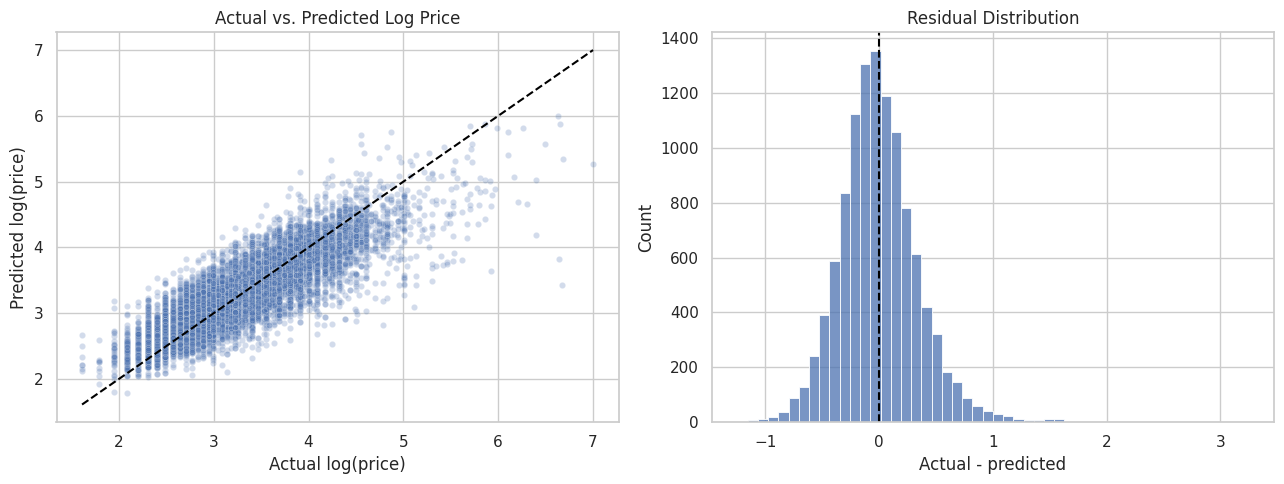

In [35]:
test_output = trainer.predict(tokenized_dataset["test"])
actual_log_price = np.asarray(test_output.label_ids).reshape(-1)
predicted_log_price = np.asarray(test_output.predictions).reshape(-1)
residuals = actual_log_price - predicted_log_price

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    x=actual_log_price,
    y=predicted_log_price,
    alpha=0.25,
    s=20,
    ax=axes[0],
)
limits = [
    min(actual_log_price.min(), predicted_log_price.min()),
    max(actual_log_price.max(), predicted_log_price.max()),
]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 7. 新しいレビューと構造化変数から価格を予測

新しいレビュー本文と構造化変数を学習時と同じ `build_model_text` で1つの文章へ変換し、tokenizeして学習済みモデルへ入力する関数を定義する。評価モードと勾配無効化で推論し、実際にモデルへ渡した文章、予測log価格、指数変換したドル価格を返す。最後に入力例を使って推論形式を示す。


In [36]:
def predict_price(
    description,
    *,
    points=None,
    country=None,
    designation=None,
    province=None,
    region_1=None,
    region_2=None,
    variety=None,
    winery=None,
):
    text = build_model_text(
        description=description,
        points=points,
        country=country,
        designation=designation,
        province=province,
        region_1=region_1,
        region_2=region_2,
        variety=variety,
        winery=winery,
    )
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)
    model.eval()
    with torch.no_grad():
        predicted_log_price = model(**inputs).logits.squeeze().item()
    return {
        "model_text": text,
        "log_price": predicted_log_price,
        "price_usd": float(np.exp(predicted_log_price)),
    }


example_prediction = predict_price(
    description=(
        "A rich and structured red wine with ripe blackberry, dark chocolate, "
        "cedar and a long, balanced finish."
    ),
    points=92,
    country="US",
    province="California",
    region_1="Napa Valley",
    variety="Cabernet Sauvignon",
    winery="Example Winery",
)
print(example_prediction)

{'model_text': 'Points: 92 | Country: US | Designation: Unknown | Province: California | Region 1: Napa Valley | Region 2: Unknown | Variety: Cabernet Sauvignon | Winery: Example Winery | Review: A rich and structured red wine with ripe blackberry, dark chocolate, cedar and a long, balanced finish.', 'log_price': 3.765625, 'price_usd': 43.19069160819034}
